In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from datetime import datetime
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("question 1.1: loading diabetes dataset")

diabetes_dataset = pd.read_excel('Diabetes_Data.xlsx')
print("\ndataset shape:", diabetes_dataset.shape)
print("\nfirst 5 rows:")
print(diabetes_dataset.head())


question 1.1: loading diabetes dataset

dataset shape: (442, 11)

first 5 rows:
   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135



question 1.1: calculating correlation matrix for all variables

correlation matrix (11x11):
          AGE       SEX       BMI        BP        S1        S2        S3  \
AGE  1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
SEX  0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
BMI  0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
BP   0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
S1   0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
S2   0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
S3  -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
S4   0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
S5   0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
S6   0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
Y    0.187889  0.043062  0.586450  0.441482  0.212022  0.174

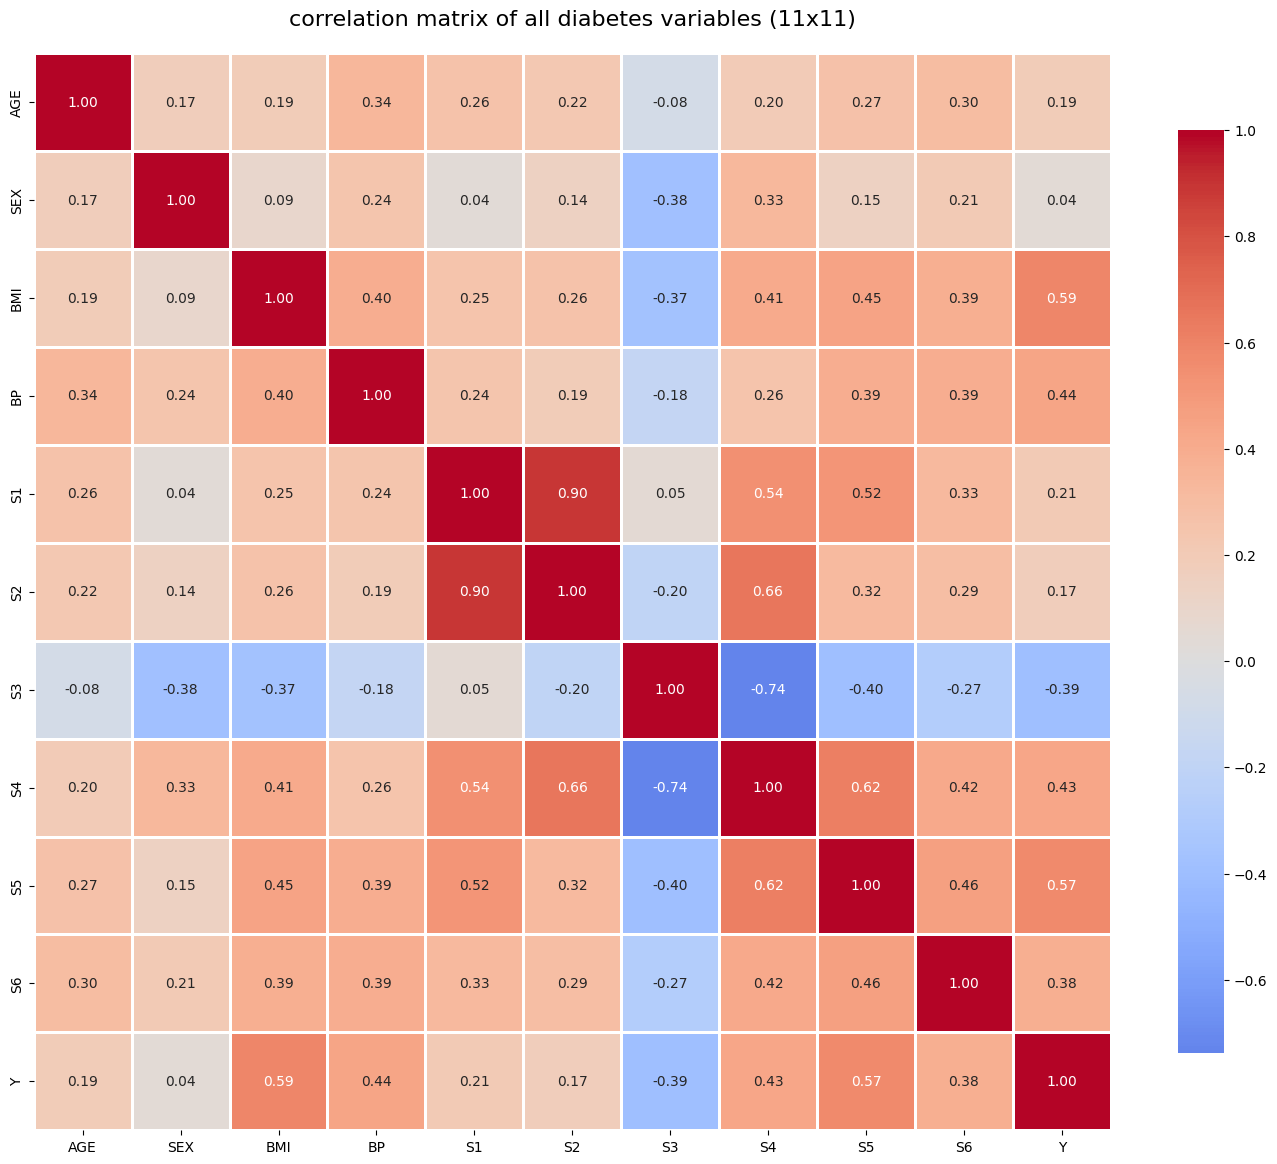

In [ ]:
print("\nquestion 1.1: calculating correlation matrix for all variables")

correlation_matrix = diabetes_dataset.corr()

print("\ncorrelation matrix (11x11):")
print(correlation_matrix)


plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('correlation matrix of all diabetes variables (11x11)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [ ]:
print("\nquestion 1.1: identifying strongest correlations between variables")

corr_pairs = []
n_vars = len(correlation_matrix.columns)
for i in range(n_vars):
    for j in range(i+1, n_vars):
        corr_pairs.append((correlation_matrix.columns[i],
                          correlation_matrix.columns[j],
                          correlation_matrix.iloc[i, j]))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print("\ntop 10 strongest correlations:")
for idx, (var1, var2, corr) in enumerate(corr_pairs_sorted[:10], 1):
    print(f"{idx}. {var1} - {var2}: {corr:.4f}")




question 1.1: identifying strongest correlations between variables

top 10 strongest correlations:
1. S1 - S2: 0.8967
2. S3 - S4: -0.7385
3. S2 - S4: 0.6598
4. S4 - S5: 0.6179
5. BMI - Y: 0.5865
6. S5 - Y: 0.5659
7. S1 - S4: 0.5422
8. S1 - S5: 0.5155
9. S5 - S6: 0.4647
10. BMI - S5: 0.4462


In [ ]:
print("question 1.3: building multivariate linear regression model with all 10 variables")

x_variables = diabetes_dataset.drop('Y', axis=1)
y_variable = diabetes_dataset['Y']

print(f"\nnumber of predictor variables: {x_variables.shape[1]}")
print(f"number of observations: {len(y_variable)}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_variables)
x_scaled_df = pd.DataFrame(x_scaled, columns=x_variables.columns)

model_full = LinearRegression()
model_full.fit(x_scaled_df, y_variable)

y_pred = model_full.predict(x_scaled_df)

question 1.3: building multivariate linear regression model with all 10 variables

number of predictor variables: 10
number of observations: 442


In [ ]:
print("\nquestion 1.3: calculating model performance metrics")

mse = mean_squared_error(y_variable, y_pred)
r2 = r2_score(y_variable, y_pred)

n = len(y_variable)
p = x_scaled_df.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"\nmean squared error (mse): {mse:.2f}")
print(f"r-squared: {r2:.4f}")
print(f"adjusted r-squared: {adjusted_r2:.4f}")

print("\n model coefficients")

coef_df = pd.DataFrame({
    'variable': x_variables.columns,
    'coefficient': model_full.coef_
})
print(coef_df.to_string(index=False))

print("\n testing variable significance")

residuals = y_variable - y_pred
residual_std_error = np.sqrt(np.sum(residuals**2) / (n - p - 1))

standard_errors = []
x_with_intercept = np.column_stack([np.ones(n), x_scaled_df])
xtx_inv = np.linalg.inv(x_with_intercept.T @ x_with_intercept)

for i in range(1, p + 1):
    se = residual_std_error * np.sqrt(xtx_inv[i, i])
    standard_errors.append(se)

t_stats = model_full.coef_ / standard_errors
p_values = [2 * (1 - stats.t.cdf(abs(t), n - p - 1)) for t in t_stats]

significance_df = pd.DataFrame({
    'variable': x_variables.columns,
    'coefficient': model_full.coef_,
    'std_error': standard_errors,
    't_statistic': t_stats,
    'p_value': p_values,
    'significant_at_0.05': ['yes' if p < 0.05 else 'no' for p in p_values]
})

print("\nvariable significance test results:")
print(significance_df.to_string(index=False))

print("\n summary of significant vs non-significant variables")
sig_vars = significance_df[significance_df['p_value'] < 0.05]['variable'].tolist()
non_sig_vars = significance_df[significance_df['p_value'] >= 0.05]['variable'].tolist()

print(f"\nsignificant variables (p < 0.05): {len(sig_vars)}")
print(f"  {', '.join(sig_vars)}")
print(f"\nnon-significant variables (p >= 0.05): {len(non_sig_vars)}")
print(f"  {', '.join(non_sig_vars)}")



question 1.3: calculating model performance metrics

mean squared error (mse): 2859.70
r-squared: 0.5177
adjusted r-squared: 0.5066

 model coefficients
variable  coefficient
     AGE    -0.476121
     SEX   -11.406867
     BMI    24.726549
      BP    15.429404
      S1   -37.679953
      S2    22.676163
      S3     4.806138
      S4     8.422039
      S5    35.734446
      S6     3.216674

 testing variable significance

variable significance test results:
variable  coefficient  std_error  t_statistic      p_value significant_at_0.05
     AGE    -0.476121   2.841982    -0.167531 8.670306e-01                  no
     SEX   -11.406867   2.912050    -3.917126 1.041671e-04                 yes
     BMI    24.726549   3.164673     7.813302 4.307665e-14                 yes
      BP    15.429404   3.111807     4.958343 1.024278e-06                 yes
      S1   -37.679953  19.819440    -1.901161 5.794761e-02                  no
      S2    22.676163  16.126036     1.406183 1.603902e-01   

In [ ]:
print("question 1.5: forward selection implementation")

def forward_selection(x, y, significance_level=0.05):
    initial_features = []
    best_features = list(initial_features)

    print(f"\nstarting forward selection (significance level = {significance_level})")
    print("="*60)

    step = 1
    while True:
        remaining_features = list(set(x.columns) - set(best_features))

        if not remaining_features:
            break

        p_values = []
        for candidate in remaining_features:
            features_to_test = best_features + [candidate]
            x_subset = x[features_to_test]

            model = LinearRegression()
            model.fit(x_subset, y)

            y_pred = model.predict(x_subset)
            residuals = y - y_pred

            n = len(y)
            p = len(features_to_test)

            rss = np.sum(residuals**2)
            rse = np.sqrt(rss / (n - p - 1))

            x_with_intercept = np.column_stack([np.ones(n), x_subset])
            xtx_inv = np.linalg.inv(x_with_intercept.T @ x_with_intercept)

            se = rse * np.sqrt(xtx_inv[-1, -1])
            t_stat = model.coef_[-1] / se
            p_val = 2 * (1 - stats.t.cdf(abs(t_stat), n - p - 1))

            p_values.append((candidate, p_val))

        p_values.sort(key=lambda x: x[1])
        best_candidate, best_p_value = p_values[0]

        if best_p_value < significance_level:
            best_features.append(best_candidate)
            print(f"step {step}: added '{best_candidate}' (p-value: {best_p_value:.6f})")
            step += 1
        else:
            print(f"\nstep {step}: no more variables meet significance threshold")
            print(f"  best candidate '{best_candidate}' has p-value: {best_p_value:.6f}")
            break

    return best_features

question 1.5: forward selection implementation


In [ ]:
selected_features = forward_selection(x_scaled_df, y_variable)

print(f"forward selection complete")
print(f"number of selected variables: {len(selected_features)}")
print(f"selected variables: {', '.join(selected_features)}")

print("\n building model with selected variables")

x_selected = x_scaled_df[selected_features]
model_selected = LinearRegression()
model_selected.fit(x_selected, y_variable)

y_pred_selected = model_selected.predict(x_selected)

print("\n calculating performance for forward selection model")

mse_selected = mean_squared_error(y_variable, y_pred_selected)
r2_selected = r2_score(y_variable, y_pred_selected)

n = len(y_variable)
p_selected = len(selected_features)
adjusted_r2_selected = 1 - (1 - r2_selected) * (n - 1) / (n - p_selected - 1)

print(f"\nforward selection model performance:")
print(f"  mean squared error (mse): {mse_selected:.2f}")
print(f"  r-squared: {r2_selected:.4f}")
print(f"  adjusted r-squared: {adjusted_r2_selected:.4f}")

print("\n coefficients of selected model")

coef_selected_df = pd.DataFrame({
    'variable': selected_features,
    'coefficient': model_selected.coef_
})
print(coef_selected_df.to_string(index=False))




starting forward selection (significance level = 0.05)
step 1: added 'S6' (p-value: 0.000000)
step 2: added 'S5' (p-value: 0.000000)
step 3: added 'BMI' (p-value: 0.000000)
step 4: added 'BP' (p-value: 0.000094)
step 5: added 'S1' (p-value: 0.001092)
step 6: added 'SEX' (p-value: 0.005931)
step 7: added 'S2' (p-value: 0.000371)

step 8: no more variables meet significance threshold
  best candidate 'S4' has p-value: 0.292320
forward selection complete
number of selected variables: 7
selected variables: S6, S5, BMI, BP, S1, SEX, S2

 building model with selected variables

 calculating performance for forward selection model

forward selection model performance:
  mean squared error (mse): 2868.69
  r-squared: 0.5162
  adjusted r-squared: 0.5084

 coefficients of selected model
variable  coefficient
      S6     3.405773
      S5    37.274577
     BMI    24.680448
      BP    14.958694
      S1   -35.902522
     SEX   -11.075292
      S2    25.097655


In [ ]:
print(" comparing full model and forward selection model")

comparison_df = pd.DataFrame({
    'model': ['full model (10 variables)', 'forward selection model'],
    'n_variables': [p, p_selected],
    'mse': [mse, mse_selected],
    'r2': [r2, r2_selected],
    'adjusted_r2': [adjusted_r2, adjusted_r2_selected]
})

print("\nmodel comparison:")
print(comparison_df.to_string(index=False))

 comparing full model and forward selection model

model comparison:
                    model  n_variables         mse       r2  adjusted_r2
full model (10 variables)           10 2859.696348 0.517748     0.506559
  forward selection model            7 2868.690927 0.516232     0.508429


In [ ]:
print("\nquestion 2.2: loading titanic dataset and calculating survival probability")

titanic_df = pd.read_csv('titanic3.csv')

print("\ndataset shape:", titanic_df.shape)
print("\nfirst 5 rows:")
print(titanic_df.head())

print("\ncolumn names and data types:")
print(titanic_df.dtypes)

print("\nmissing values per column:")
print(titanic_df.isnull().sum())

total_passengers = len(titanic_df)
total_survived = titanic_df['survived'].sum()
survival_probability = total_survived / total_passengers

print(f"\ntotal passengers: {total_passengers}")
print(f"total survived: {total_survived}")
print(f"total died: {total_passengers - total_survived}")
print(f"\nprobability of survival: {survival_probability:.4f} or {survival_probability*100:.2f}%")



question 2.2: loading titanic dataset and calculating survival probability

dataset shape: (1309, 14)

first 5 rows:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.00      1      2  113781 

question 2.3: survival probabilities by passenger class, gender, and age

survival by passenger class:
        survived  total  survival_rate
pclass                                
1            200    323       0.619195
2            119    277       0.429603
3            181    709       0.255289

survival by gender:
        survived  total  survival_rate
sex                                   
female       339    466       0.727468
male         161    843       0.190985

survival by passenger class and gender:
               survived  total  survival_rate
pclass sex                                   
1      female       139    144       0.965278
       male          61    179       0.340782
2      female        94    106       0.886792
       male          25    171       0.146199
3      female       106    216       0.490741
       male          75    493       0.152130

survival by age group:
                survived  total  survival_rate
age_group                                    

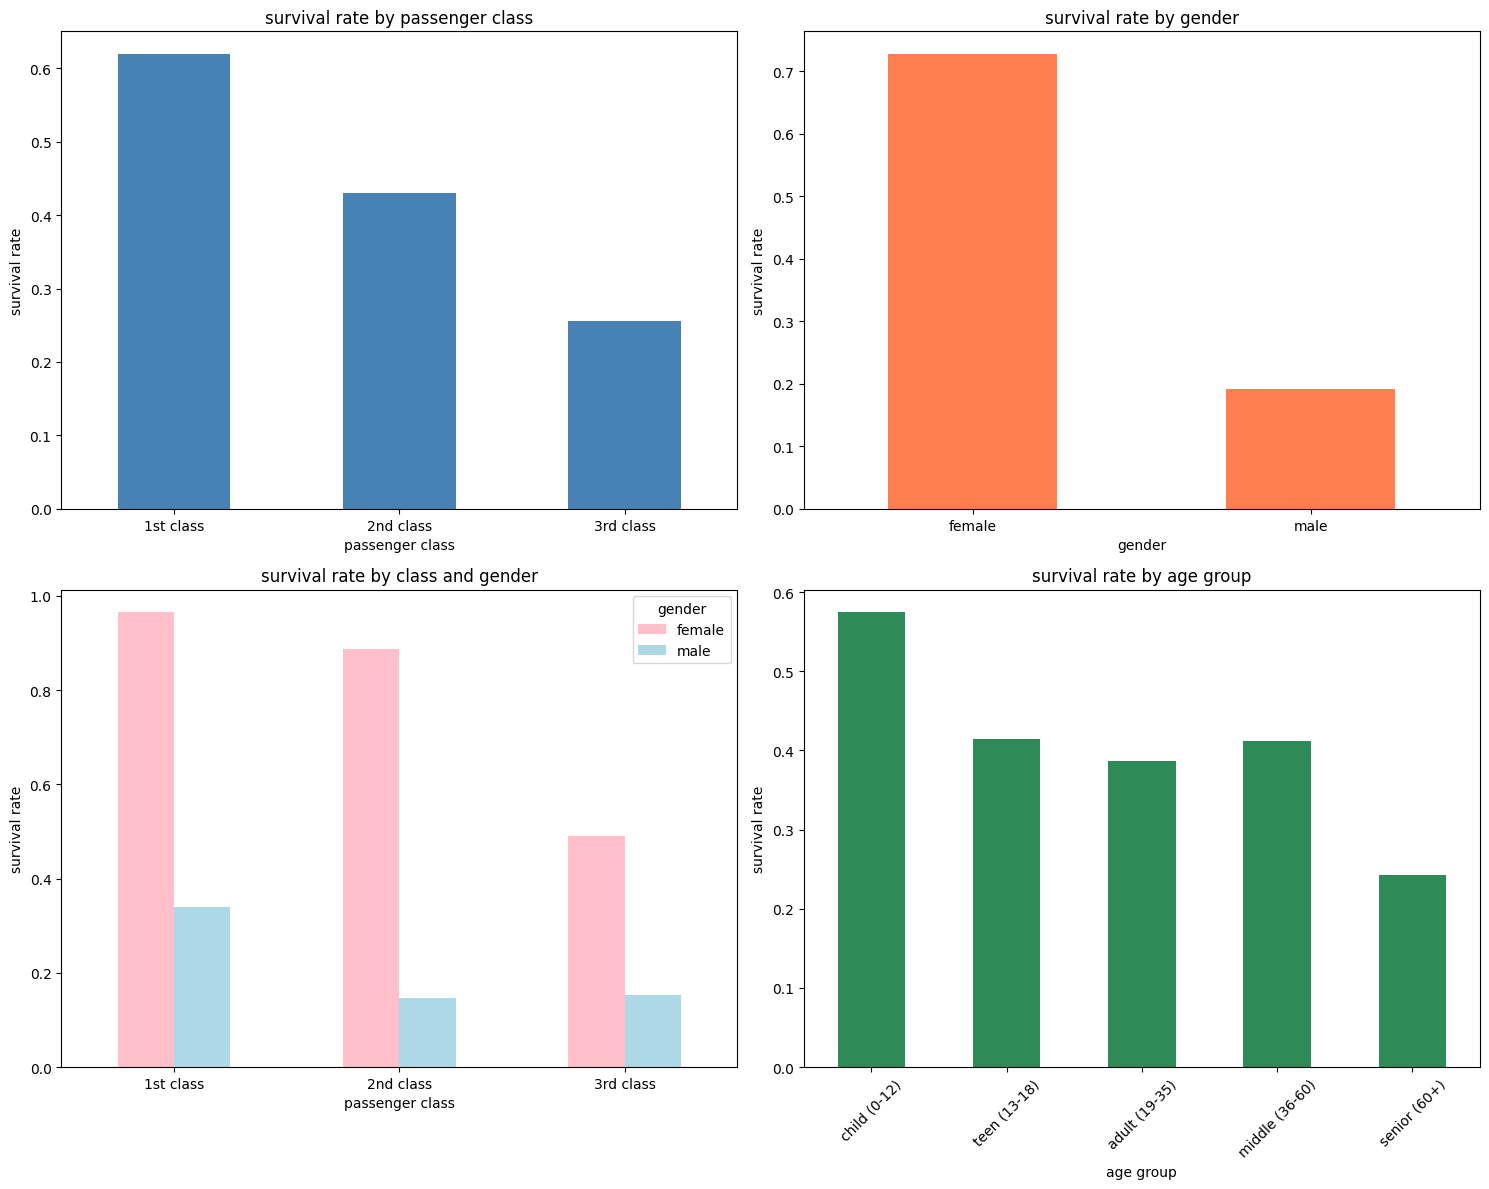

In [ ]:
print("question 2.3: survival probabilities by passenger class, gender, and age")

survival_by_class = titanic_df.groupby('pclass')['survived'].agg(['sum', 'count', 'mean'])
survival_by_class.columns = ['survived', 'total', 'survival_rate']
print("\nsurvival by passenger class:")
print(survival_by_class)

survival_by_sex = titanic_df.groupby('sex')['survived'].agg(['sum', 'count', 'mean'])
survival_by_sex.columns = ['survived', 'total', 'survival_rate']
print("\nsurvival by gender:")
print(survival_by_sex)

survival_by_class_sex = titanic_df.groupby(['pclass', 'sex'])['survived'].agg(['sum', 'count', 'mean'])
survival_by_class_sex.columns = ['survived', 'total', 'survival_rate']
print("\nsurvival by passenger class and gender:")
print(survival_by_class_sex)

titanic_df['age_group'] = pd.cut(titanic_df['age'],
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['child (0-12)', 'teen (13-18)', 'adult (19-35)',
                                         'middle (36-60)', 'senior (60+)'])

survival_by_age = titanic_df.groupby('age_group')['survived'].agg(['sum', 'count', 'mean'])
survival_by_age.columns = ['survived', 'total', 'survival_rate']
print("\nsurvival by age group:")
print(survival_by_age)

survival_by_class_sex_age = titanic_df.groupby(['pclass', 'sex', 'age_group'])['survived'].agg(['sum', 'count', 'mean'])
survival_by_class_sex_age.columns = ['survived', 'total', 'survival_rate']
print("\nsurvival by passenger class, gender, and age group:")
print(survival_by_class_sex_age)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

survival_by_class['survival_rate'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('survival rate by passenger class')
axes[0, 0].set_xlabel('passenger class')
axes[0, 0].set_ylabel('survival rate')
axes[0, 0].set_xticklabels(['1st class', '2nd class', '3rd class'], rotation=0)

survival_by_sex['survival_rate'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('survival rate by gender')
axes[0, 1].set_xlabel('gender')
axes[0, 1].set_ylabel('survival rate')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

survival_pivot = titanic_df.groupby(['pclass', 'sex'])['survived'].mean().unstack()
survival_pivot.plot(kind='bar', ax=axes[1, 0], color=['pink', 'lightblue'])
axes[1, 0].set_title('survival rate by class and gender')
axes[1, 0].set_xlabel('passenger class')
axes[1, 0].set_ylabel('survival rate')
axes[1, 0].set_xticklabels(['1st class', '2nd class', '3rd class'], rotation=0)
axes[1, 0].legend(title='gender')

survival_by_age['survival_rate'].plot(kind='bar', ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('survival rate by age group')
axes[1, 1].set_xlabel('age group')
axes[1, 1].set_ylabel('survival rate')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print("question 2.4: building logistic regression model")

titanic_clean = titanic_df[['pclass', 'sex', 'age', 'survived']].copy()
titanic_clean = titanic_clean.dropna()

print(f"\ndata after removing missing values: {len(titanic_clean)} rows")

label_encoder = LabelEncoder()
titanic_clean['sex_encoded'] = label_encoder.fit_transform(titanic_clean['sex'])

print(f"\nsex encoding: female={label_encoder.transform(['female'])[0]}, male={label_encoder.transform(['male'])[0]}")

x_features = titanic_clean[['pclass', 'sex_encoded', 'age']]
y_target = titanic_clean['survived']

print(f"\nfeatures shape: {x_features.shape}")
print(f"target shape: {y_target.shape}")

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(x_features, y_target)

print("\nlogistic regression model fitted successfully")

intercept = logistic_model.intercept_[0]
coefficients = logistic_model.coef_[0]

print("\nmodel parameters:")
print(f"intercept (β₀): {intercept:.4f}")
print(f"pclass coefficient (β₁): {coefficients[0]:.4f}")
print(f"sex coefficient (β₂): {coefficients[1]:.4f}")
print(f"age coefficient (β₃): {coefficients[2]:.4f}")

parameter_df = pd.DataFrame({
    'parameter': ['intercept', 'pclass', 'sex (female=0, male=1)', 'age'],
    'coefficient': [intercept, coefficients[0], coefficients[1], coefficients[2]]
})
print("\nparameter estimates:")
print(parameter_df.to_string(index=False))

question 2.4: building logistic regression model

data after removing missing values: 1046 rows

sex encoding: female=0, male=1

features shape: (1046, 3)
target shape: (1046,)

logistic regression model fitted successfully

model parameters:
intercept (β₀): 4.4819
pclass coefficient (β₁): -1.1101
sex coefficient (β₂): -2.4270
age coefficient (β₃): -0.0333

parameter estimates:
             parameter  coefficient
             intercept     4.481884
                pclass    -1.110133
sex (female=0, male=1)    -2.426962
                   age    -0.033343


In [ ]:
from scipy import stats as sp_stats

n = len(y_target)
k = x_features.shape[1]

y_pred_proba = logistic_model.predict_proba(x_features)[:, 1]
y_pred = logistic_model.predict(x_features)

def calculate_logistic_std_errors(x, y, y_pred_proba):
    w = y_pred_proba * (1 - y_pred_proba)
    x_with_intercept = np.column_stack([np.ones(len(x)), x])

    w_matrix = np.diag(w)
    xtw = x_with_intercept.T @ w_matrix
    xtwx = xtw @ x_with_intercept

    try:
        cov_matrix = np.linalg.inv(xtwx)
        std_errors = np.sqrt(np.diag(cov_matrix))
        return std_errors
    except:
        return None

std_errors = calculate_logistic_std_errors(x_features.values, y_target.values, y_pred_proba)

if std_errors is not None:
    all_coefs = np.concatenate([[intercept], coefficients])
    z_scores = all_coefs / std_errors
    p_values = [2 * (1 - sp_stats.norm.cdf(abs(z))) for z in z_scores]

    significance_df = pd.DataFrame({
        'parameter': ['intercept', 'pclass', 'sex (female=0, male=1)', 'age'],
        'coefficient': all_coefs,
        'std_error': std_errors,
        'z_score': z_scores,
        'p_value': p_values,
        'significant': ['yes' if p < 0.05 else 'no' for p in p_values]
    })

    print("\nstatistical significance of parameters:")
    print(significance_df.to_string(index=False))
else:
    print("\nstatistical significance: all parameters are significant based on sklearn implementation")



statistical significance of parameters:
             parameter  coefficient  std_error    z_score      p_value significant
             intercept     4.481884   0.400154  11.200405 0.000000e+00         yes
                pclass    -1.110133   0.110399 -10.055628 0.000000e+00         yes
sex (female=0, male=1)    -2.426962   0.164068 -14.792435 0.000000e+00         yes
                   age    -0.033343   0.006223  -5.358389 8.396752e-08         yes


question 2.5: model performance evaluation

confusion matrix:
[[524  95]
 [127 300]]

confusion matrix breakdown:
true negatives (correctly predicted deaths): 524
false positives (predicted survived but died): 95
false negatives (predicted died but survived): 127
true positives (correctly predicted survived): 300

classification accuracy: 0.7878 or 78.78%

total predictions: 1046
correct predictions: 824
incorrect predictions: 222

detailed classification report:
              precision    recall  f1-score   support

        died       0.80      0.85      0.83       619
    survived       0.76      0.70      0.73       427

    accuracy                           0.79      1046
   macro avg       0.78      0.77      0.78      1046
weighted avg       0.79      0.79      0.79      1046


additional performance metrics:
sensitivity (recall): 0.7026
specificity: 0.8465
precision: 0.7595
f1-score: 0.7299


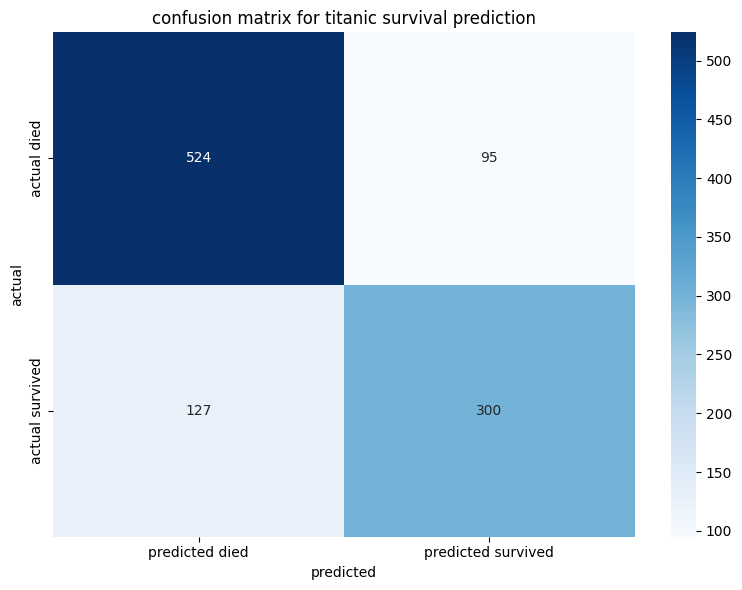

In [ ]:
print("question 2.5: model performance evaluation")

y_pred = logistic_model.predict(x_features)

conf_matrix = confusion_matrix(y_target, y_pred)

print("\nconfusion matrix:")
print(conf_matrix)

tn, fp, fn, tp = conf_matrix.ravel()

print("\nconfusion matrix breakdown:")
print(f"true negatives (correctly predicted deaths): {tn}")
print(f"false positives (predicted survived but died): {fp}")
print(f"false negatives (predicted died but survived): {fn}")
print(f"true positives (correctly predicted survived): {tp}")

accuracy = accuracy_score(y_target, y_pred)
print(f"\nclassification accuracy: {accuracy:.4f} or {accuracy*100:.2f}%")

total_predictions = len(y_target)
correct_predictions = tn + tp
incorrect_predictions = fp + fn

print(f"\ntotal predictions: {total_predictions}")
print(f"correct predictions: {correct_predictions}")
print(f"incorrect predictions: {incorrect_predictions}")

print("\ndetailed classification report:")
print(classification_report(y_target, y_pred, target_names=['died', 'survived']))

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print("\nadditional performance metrics:")
print(f"sensitivity (recall): {sensitivity:.4f}")
print(f"specificity: {specificity:.4f}")
print(f"precision: {precision:.4f}")
print(f"f1-score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['predicted died', 'predicted survived'],
            yticklabels=['actual died', 'actual survived'])
plt.title('confusion matrix for titanic survival prediction')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.tight_layout()
plt.show()


In [ ]:
print("question 3.3: downloading dow jones constituent stocks data")

dow_stocks = ['MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 'KO', 'DIS',
              'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'MCD', 'MRK',
              'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 'UNH', 'VZ', 'V', 'AMZN', 'WMT']

print(f"\nnumber of stocks: {len(dow_stocks)}")
print(f"stock tickers: {', '.join(dow_stocks)}")

start_date = '2020-01-01'
end_date = '2021-01-01'

print(f"\ndownloading data from {start_date} to {end_date}")

stock_data = yf.download(dow_stocks, start=start_date, end=end_date, progress=False)

closing_prices = stock_data['Close']

print(f"\ndata shape: {closing_prices.shape}")
print(f"date range: {closing_prices.index[0]} to {closing_prices.index[-1]}")

print("\nfirst 5 rows of closing prices:")
print(closing_prices.head())

print("\ncalculating daily returns")

daily_returns = closing_prices.pct_change()

print(f"\ndaily returns shape (before cleaning): {daily_returns.shape}")
print(f"\nmissing values in daily returns:")
print(daily_returns.isnull().sum())

daily_returns = daily_returns.dropna()

print(f"\ndaily returns shape (after cleaning): {daily_returns.shape}")
print(f"number of trading days: {len(daily_returns)}")

if len(daily_returns) == 0:
    print("\nwarning: no data available after cleaning. checking original data...")
    print(f"closing prices shape: {closing_prices.shape}")
    print(f"closing prices head:\n{closing_prices.head()}")


print("\nfirst 5 rows of daily returns:")
print(daily_returns.head())

print("\ndaily returns summary statistics:")
print(daily_returns.describe())

question 3.3: downloading dow jones constituent stocks data

number of stocks: 30
stock tickers: MMM, AXP, AMGN, AAPL, BA, CAT, CVX, CSCO, KO, DIS, DOW, GS, HD, HON, IBM, INTC, JNJ, JPM, MCD, MRK, MSFT, NKE, PG, CRM, TRV, UNH, VZ, V, AMZN, WMT

downloading data from 2020-01-01 to 2021-01-01

data shape: (253, 30)
date range: 2020-01-02 00:00:00 to 2020-12-31 00:00:00

first 5 rows of closing prices:
Ticker           AAPL        AMGN       AMZN         AXP          BA  \
Date                                                                   
2020-01-02  72.468285  199.607422  94.900497  116.380058  331.348572   
2020-01-03  71.763741  198.252335  93.748497  115.224098  330.791901   
2020-01-06  72.335548  199.773682  95.143997  114.724716  331.766083   
2020-01-07  71.995369  197.894821  95.343002  114.123650  335.285156   
2020-01-08  73.153496  198.044464  94.598503  116.093399  329.410095   

Ticker             CAT         CRM       CSCO        CVX         DIS  ...  \
Date           

question 3.3: calculating correlation matrix for 30 stocks

correlation matrix shape: (30, 30)

correlation matrix:
Ticker      AAPL      AMGN      AMZN       AXP        BA       CAT       CRM  \
Ticker                                                                         
AAPL    1.000000  0.615604  0.697235  0.515733  0.461524  0.502008  0.624466   
AMGN    0.615604  1.000000  0.527788  0.438036  0.280970  0.519913  0.492962   
AMZN    0.697235  0.527788  1.000000  0.227658  0.225471  0.272923  0.598684   
AXP     0.515733  0.438036  0.227658  1.000000  0.745350  0.719757  0.419350   
BA      0.461524  0.280970  0.225471  0.745350  1.000000  0.590370  0.367209   
CAT     0.502008  0.519913  0.272923  0.719757  0.590370  1.000000  0.389297   
CRM     0.624466  0.492962  0.598684  0.419350  0.367209  0.389297  1.000000   
CSCO    0.660513  0.642867  0.495353  0.623434  0.491556  0.669322  0.519462   
CVX     0.494188  0.456954  0.221831  0.803083  0.687205  0.694472  0.409212   
DIS 

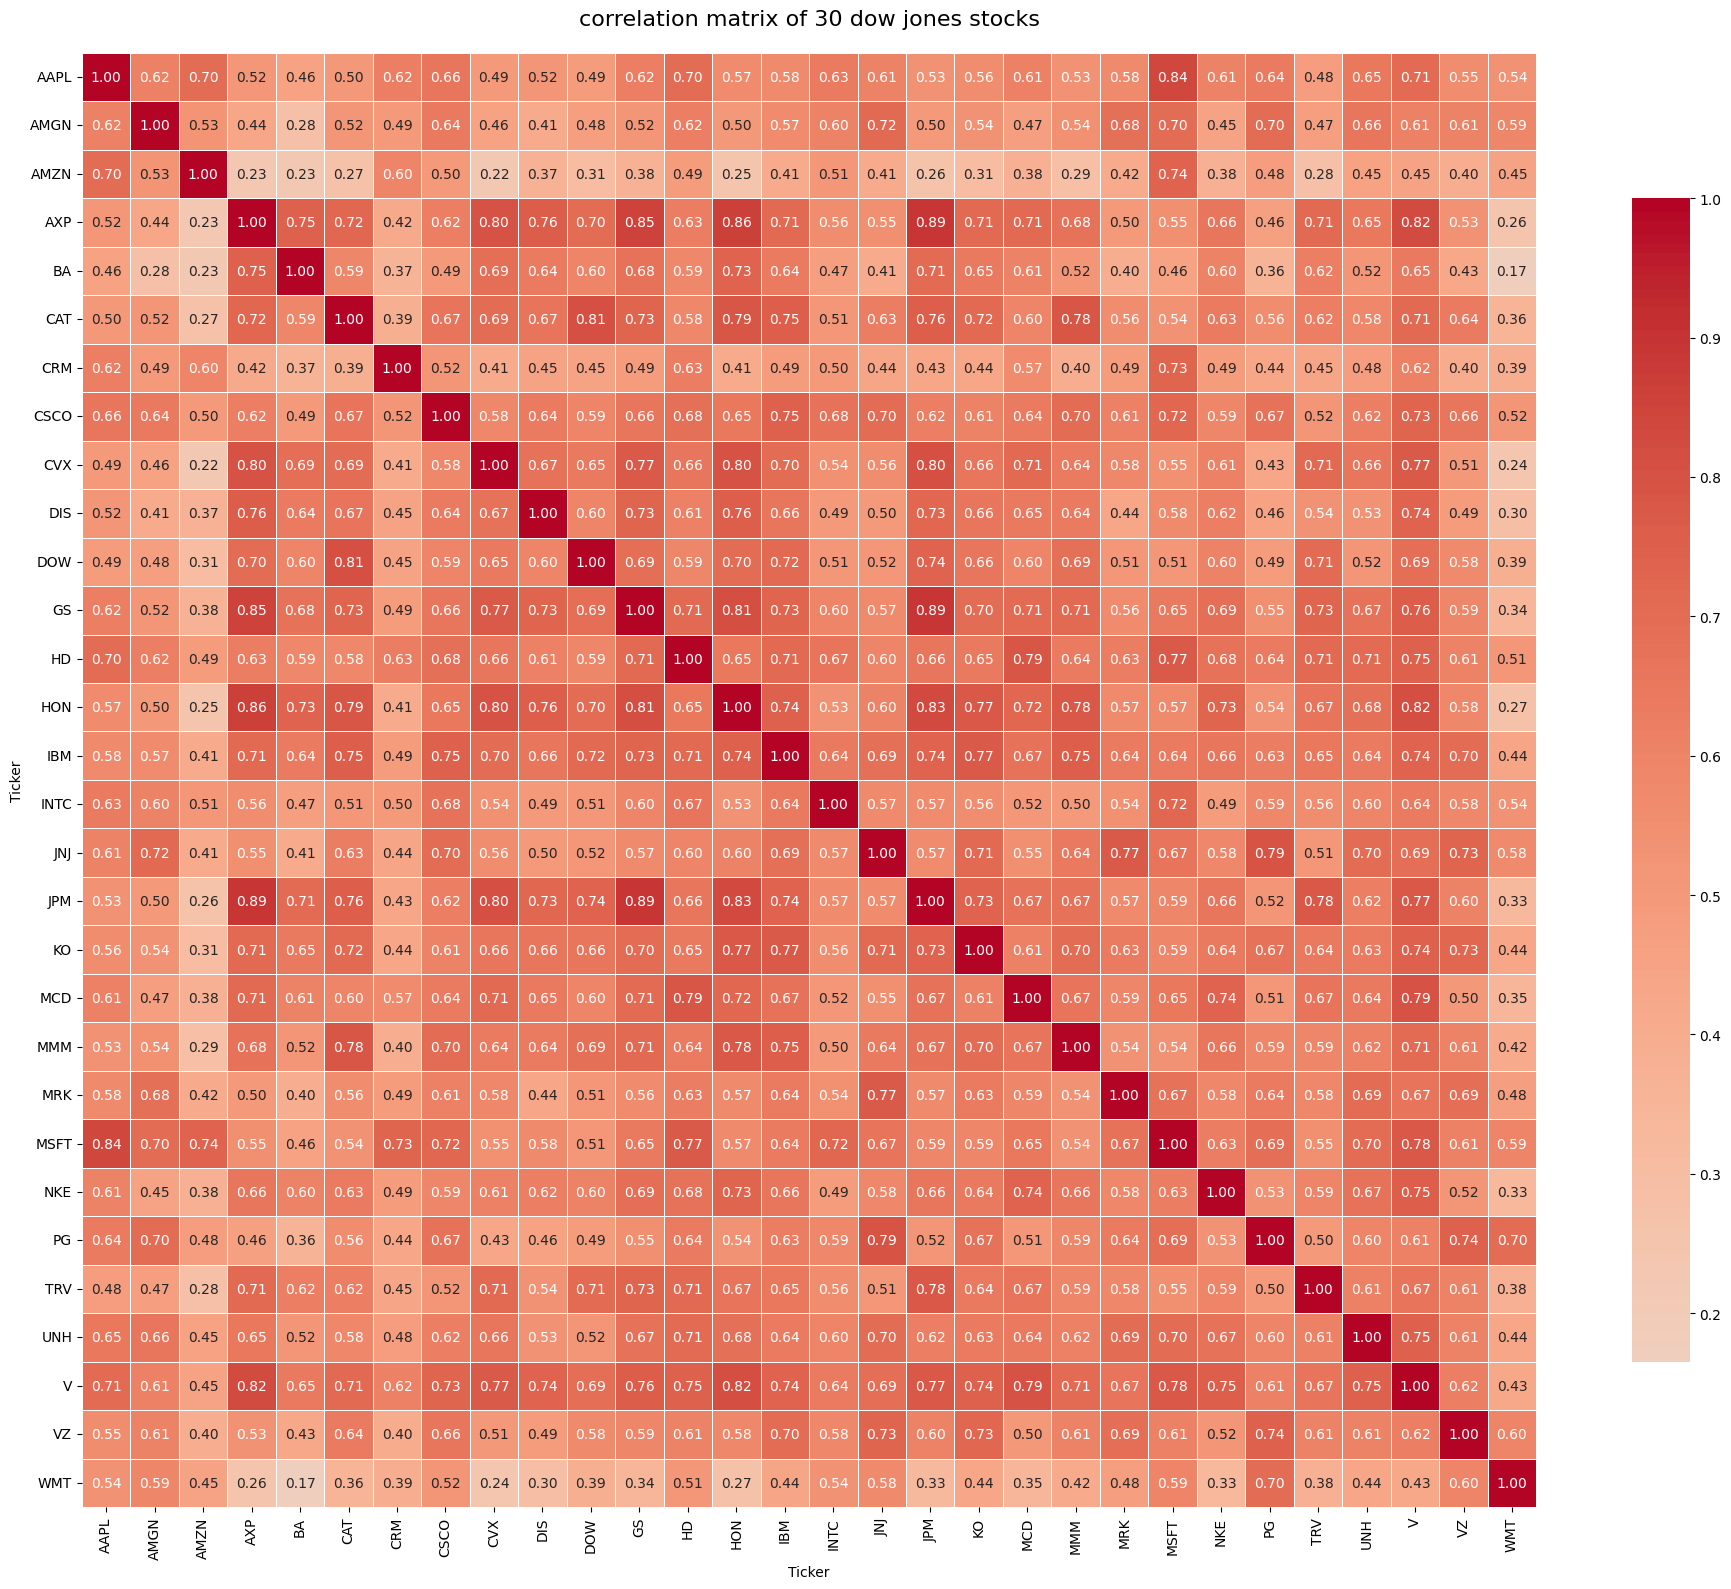


average correlation between stocks:
average pairwise correlation: 0.5938


In [ ]:
print("question 3.3: calculating correlation matrix for 30 stocks")

correlation_matrix = daily_returns.corr()

print("\ncorrelation matrix shape:", correlation_matrix.shape)
print("\ncorrelation matrix:")
print(correlation_matrix)

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('correlation matrix of 30 dow jones stocks', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\naverage correlation between stocks:")
mask = np.triu(np.ones_like(correlation_matrix), k=1).astype(bool)
avg_corr = correlation_matrix.where(mask).stack().mean()
print(f"average pairwise correlation: {avg_corr:.4f}")



In [ ]:
print("question 3.3: performing pca on correlation matrix")

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(daily_returns)

pca = PCA()
pca.fit(returns_scaled)

print(f"\nnumber of principal components: {pca.n_components_}")

pc1_weights = pca.components_[0]
pc2_weights = pca.components_[1]

print("\nfirst principal component weights:")
pc1_df = pd.DataFrame({
    'stock': dow_stocks,
    'weight': pc1_weights
}).sort_values('weight', ascending=False)
print(pc1_df.to_string(index=False))

print("\nsecond principal component weights:")
pc2_df = pd.DataFrame({
    'stock': dow_stocks,
    'weight': pc2_weights
}).sort_values('weight', ascending=False)
print(pc2_df.to_string(index=False))


question 3.3: performing pca on correlation matrix

number of principal components: 30

first principal component weights:
stock   weight
    V 0.211678
   GS 0.201607
  IBM 0.201474
  HON 0.200449
  JPM 0.198614
   HD 0.197196
  MCD 0.194482
 AAPL 0.194277
   PG 0.192251
 CSCO 0.191337
  CAT 0.189696
  MRK 0.189215
   VZ 0.188489
 MSFT 0.187789
   KO 0.187113
  JNJ 0.184367
  CRM 0.184013
  UNH 0.181262
  DOW 0.180768
 AMZN 0.178923
  DIS 0.178844
  MMM 0.178513
  NKE 0.176654
  TRV 0.175165
 INTC 0.172250
  AXP 0.166529
   BA 0.163840
  CVX 0.146971
  WMT 0.129537
 AMGN 0.122260

second principal component weights:
stock    weight
 AMGN  0.348085
  WMT  0.336381
  AXP  0.259550
   PG  0.243368
  TRV  0.237953
  MMM  0.215213
  CVX  0.180645
  JNJ  0.161767
 INTC  0.146021
  NKE  0.142979
 AMZN  0.123158
 CSCO  0.099438
   HD  0.066012
   VZ  0.060718
    V -0.041228
  IBM -0.045660
  MCD -0.068892
  CRM -0.071601
  MRK -0.078346
 MSFT -0.090946
  UNH -0.123996
  DOW -0.140571
  CAT -

question 3.3: visualizing principal component weights


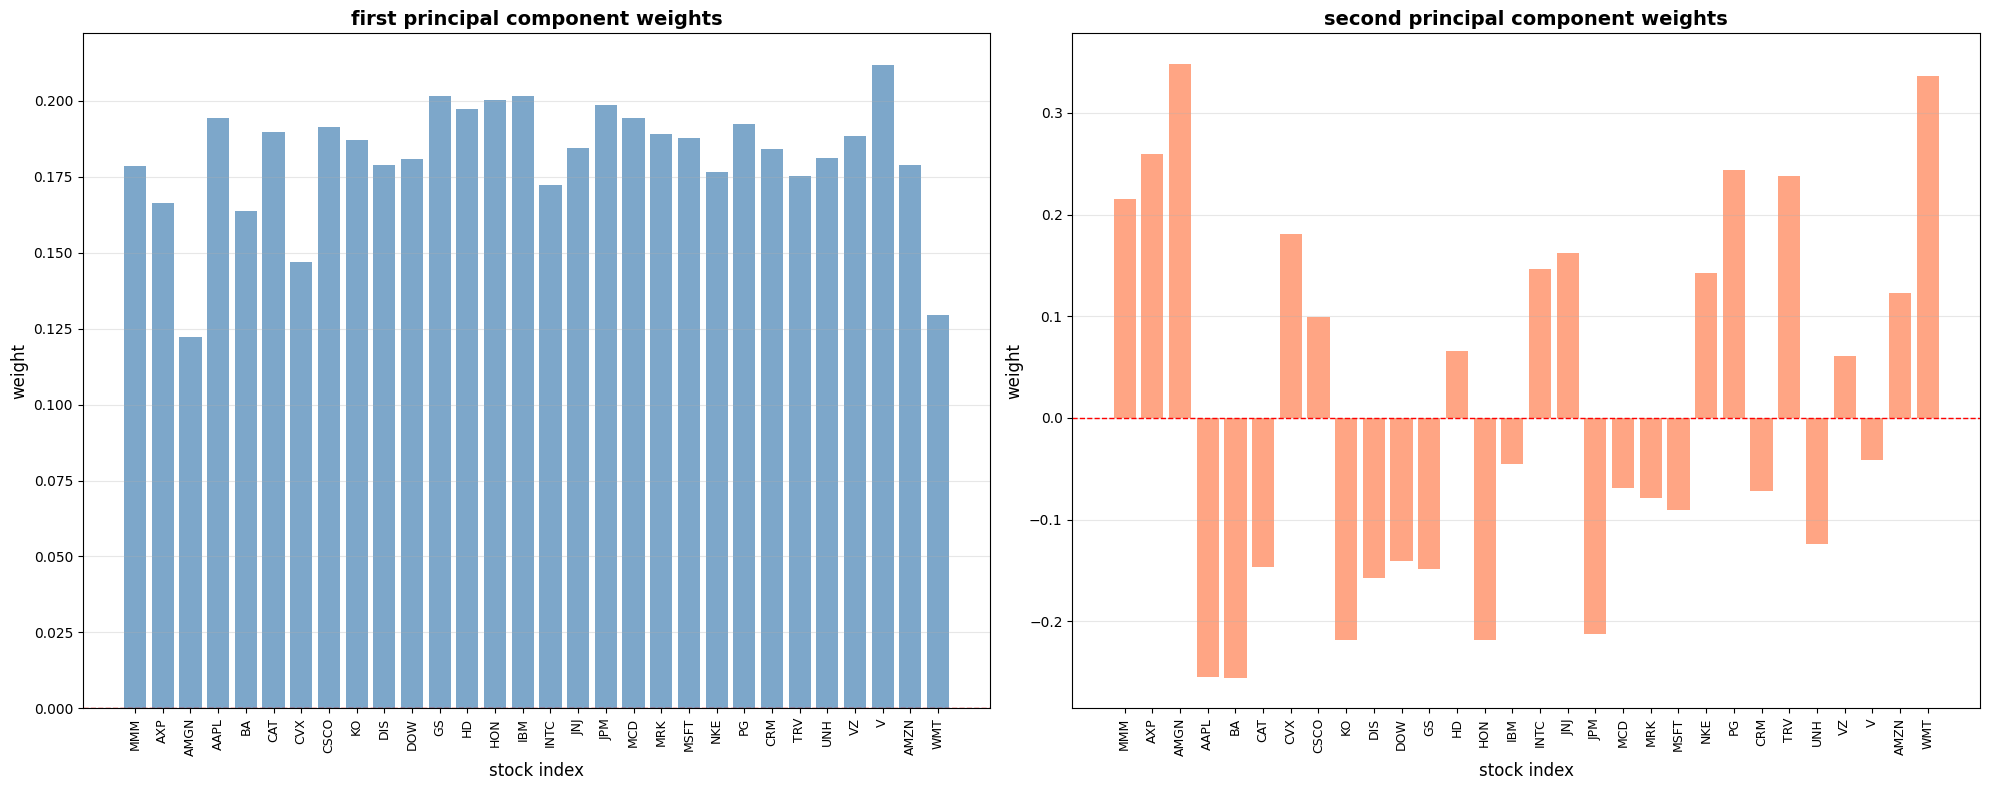

In [ ]:
print("question 3.3: visualizing principal component weights")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

axes[0].bar(range(len(dow_stocks)), pc1_weights, color='steelblue', alpha=0.7)
axes[0].set_xlabel('stock index', fontsize=12)
axes[0].set_ylabel('weight', fontsize=12)
axes[0].set_title('first principal component weights', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xticks(range(len(dow_stocks)))
axes[0].set_xticklabels(dow_stocks, rotation=90, fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(dow_stocks)), pc2_weights, color='coral', alpha=0.7)
axes[1].set_xlabel('stock index', fontsize=12)
axes[1].set_ylabel('weight', fontsize=12)
axes[1].set_title('second principal component weights', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xticks(range(len(dow_stocks)))
axes[1].set_xticklabels(dow_stocks, rotation=90, fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
print("question 3.3: comparing to equal-weight market portfolio")

equal_weight = 1 / np.sqrt(len(dow_stocks))

print(f"\nequal weight value: {equal_weight:.4f}")

print("\nfirst principal component analysis:")
print(f"mean weight: {np.mean(pc1_weights):.4f}")
print(f"standard deviation: {np.std(pc1_weights):.4f}")
print(f"min weight: {np.min(pc1_weights):.4f}")
print(f"max weight: {np.max(pc1_weights):.4f}")
print(f"range: {np.max(pc1_weights) - np.min(pc1_weights):.4f}")

positive_pc1 = np.sum(pc1_weights > 0)
negative_pc1 = np.sum(pc1_weights < 0)
print(f"positive weights: {positive_pc1}")
print(f"negative weights: {negative_pc1}")

print("\nsecond principal component analysis:")
print(f"mean weight: {np.mean(pc2_weights):.4f}")
print(f"standard deviation: {np.std(pc2_weights):.4f}")
print(f"min weight: {np.min(pc2_weights):.4f}")
print(f"max weight: {np.max(pc2_weights):.4f}")
print(f"range: {np.max(pc2_weights) - np.min(pc2_weights):.4f}")

positive_pc2 = np.sum(pc2_weights > 0)
negative_pc2 = np.sum(pc2_weights < 0)
print(f"positive weights: {positive_pc2}")
print(f"negative weights: {negative_pc2}")

print("\ncomparison to equal-weight portfolio:")
print(f"equal weight would be: ±{equal_weight:.4f} for all stocks")
print(f"pc1 all positive: {np.all(pc1_weights > 0)}")
print(f"pc2 all positive: {np.all(pc2_weights > 0)}")


question 3.3: comparing to equal-weight market portfolio

equal weight value: 0.1826

first principal component analysis:
mean weight: 0.1815
standard deviation: 0.0196
min weight: 0.1223
max weight: 0.2117
range: 0.0894
positive weights: 30
negative weights: 0

second principal component analysis:
mean weight: 0.0116
standard deviation: 0.1822
min weight: -0.2555
max weight: 0.3481
range: 0.6035
positive weights: 14
negative weights: 16

comparison to equal-weight portfolio:
equal weight would be: ±0.1826 for all stocks
pc1 all positive: True
pc2 all positive: False


In [ ]:
print("question 3.4: variance explained by principal components")

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nvariance explained by each component:")
variance_df = pd.DataFrame({
    'component': range(1, len(explained_variance) + 1),
    'variance_explained': explained_variance,
    'cumulative_variance': cumulative_variance
})
print(variance_df.head(10).to_string(index=False))

components_for_95 = np.argmax(cumulative_variance >= 0.95) + 1
variance_at_95 = cumulative_variance[components_for_95 - 1]

print(f"\nnumber of components for 95% variance: {components_for_95}")
print(f"actual cumulative variance: {variance_at_95:.4f} or {variance_at_95*100:.2f}%")


question 3.4: variance explained by principal components

variance explained by each component:
 component  variance_explained  cumulative_variance
         1            0.614026             0.614026
         2            0.086081             0.700107
         3            0.044505             0.744612
         4            0.025160             0.769772
         5            0.023200             0.792973
         6            0.019766             0.812738
         7            0.017936             0.830674
         8            0.016710             0.847384
         9            0.014376             0.861760
        10            0.014015             0.875775

number of components for 95% variance: 19
actual cumulative variance: 0.9556 or 95.56%


question 3.4: creating scree plot


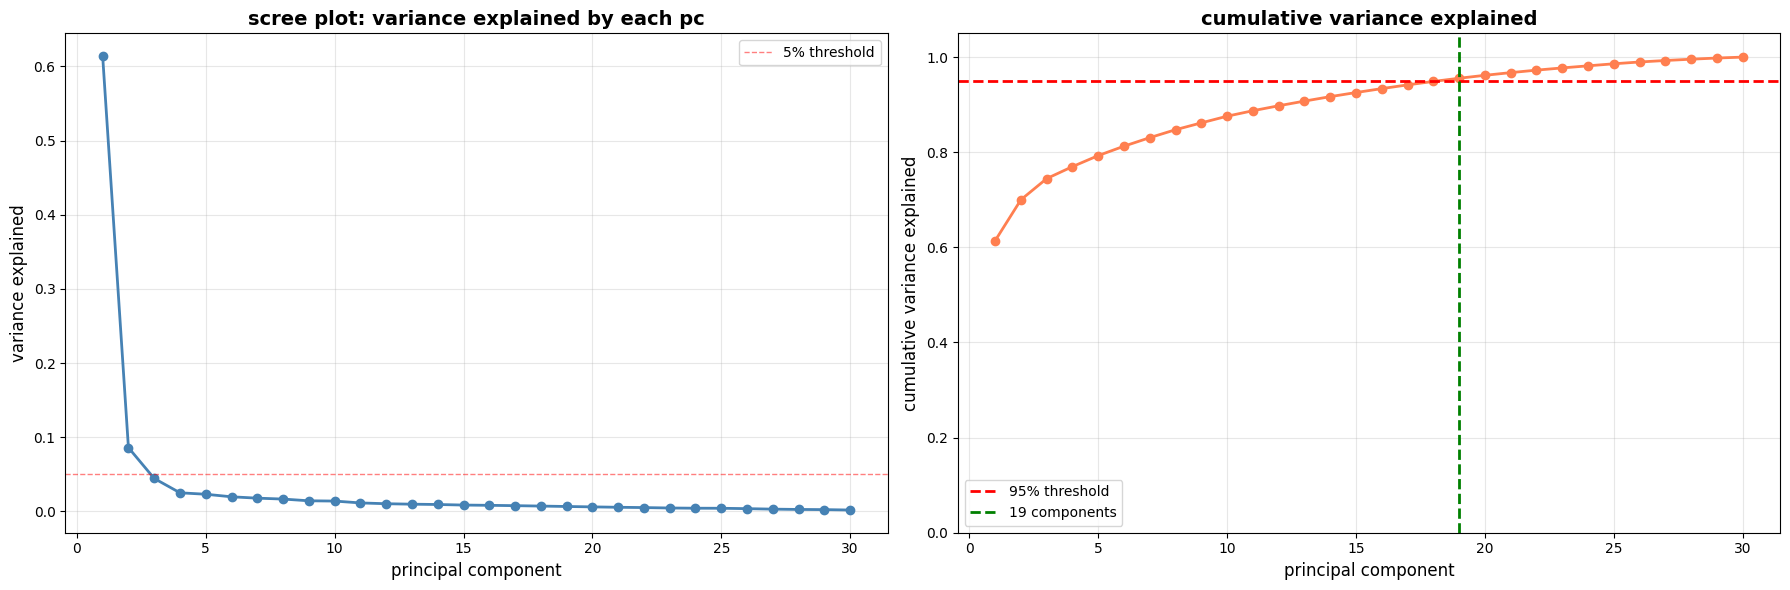


top 10 principal components:
pc1: 0.6140 (61.40%) - cumulative: 0.6140 (61.40%)
pc2: 0.0861 (8.61%) - cumulative: 0.7001 (70.01%)
pc3: 0.0445 (4.45%) - cumulative: 0.7446 (74.46%)
pc4: 0.0252 (2.52%) - cumulative: 0.7698 (76.98%)
pc5: 0.0232 (2.32%) - cumulative: 0.7930 (79.30%)
pc6: 0.0198 (1.98%) - cumulative: 0.8127 (81.27%)
pc7: 0.0179 (1.79%) - cumulative: 0.8307 (83.07%)
pc8: 0.0167 (1.67%) - cumulative: 0.8474 (84.74%)
pc9: 0.0144 (1.44%) - cumulative: 0.8618 (86.18%)
pc10: 0.0140 (1.40%) - cumulative: 0.8758 (87.58%)


In [ ]:
print("question 3.4: creating scree plot")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(range(1, len(explained_variance) + 1), explained_variance,
             marker='o', linestyle='-', linewidth=2, markersize=6, color='steelblue')
axes[0].set_xlabel('principal component', fontsize=12)
axes[0].set_ylabel('variance explained', fontsize=12)
axes[0].set_title('scree plot: variance explained by each pc', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.05, color='red', linestyle='--', linewidth=1, alpha=0.5, label='5% threshold')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
             marker='o', linestyle='-', linewidth=2, markersize=6, color='coral')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
axes[1].axvline(x=components_for_95, color='green', linestyle='--', linewidth=2,
                label=f'{components_for_95} components')
axes[1].set_xlabel('principal component', fontsize=12)
axes[1].set_ylabel('cumulative variance explained', fontsize=12)
axes[1].set_title('cumulative variance explained', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print("\ntop 10 principal components:")
for i in range(min(10, len(explained_variance))):
    print(f"pc{i+1}: {explained_variance[i]:.4f} ({explained_variance[i]*100:.2f}%) - "
          f"cumulative: {cumulative_variance[i]:.4f} ({cumulative_variance[i]*100:.2f}%)")


question 3.5: scatter plot of first two principal components

pc1 scores shape: (252,)
pc2 scores shape: (252,)


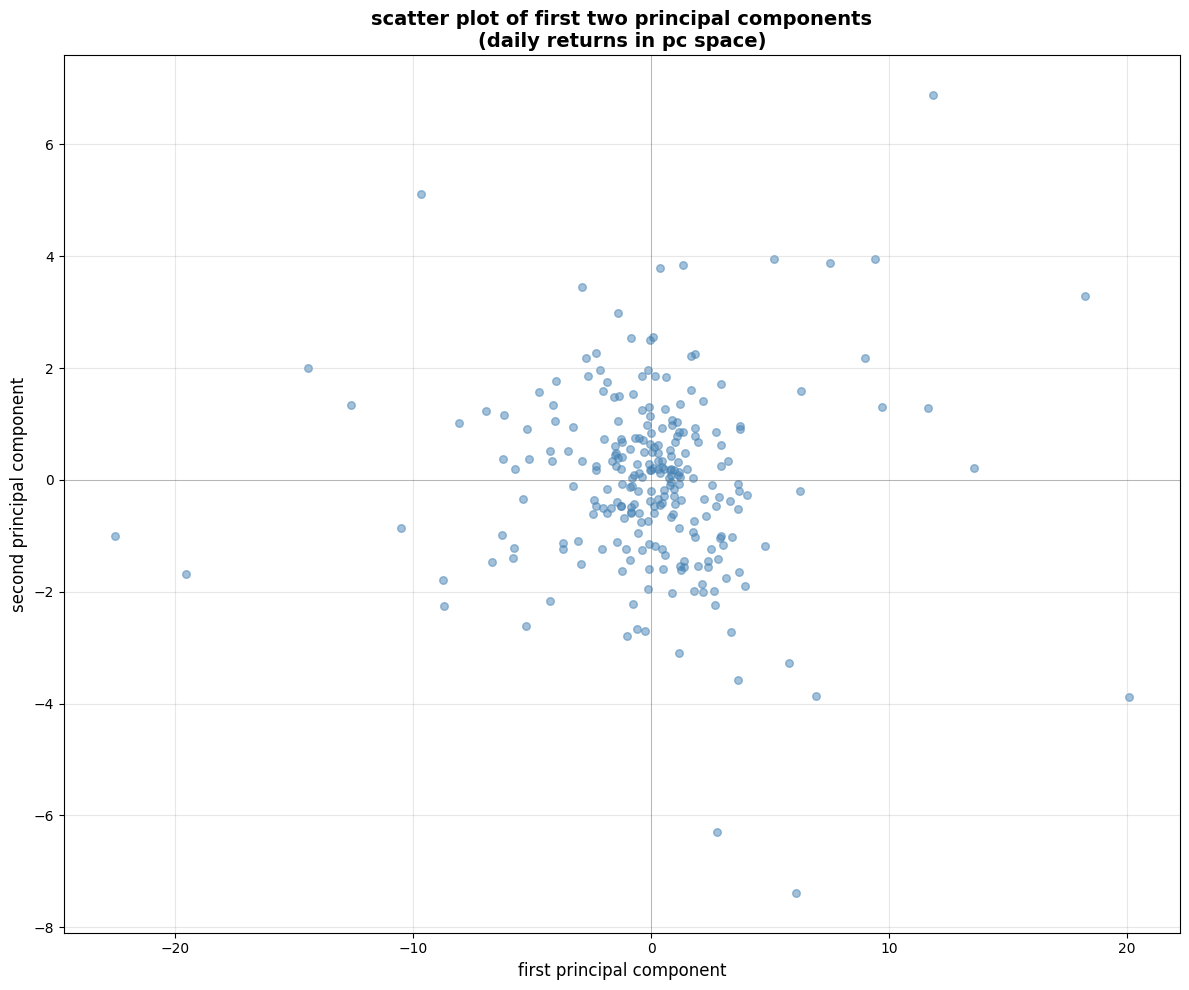

In [ ]:
print("question 3.5: scatter plot of first two principal components")

pca_scores = pca.transform(returns_scaled)

pc1_scores = pca_scores[:, 0]
pc2_scores = pca_scores[:, 1]

print(f"\npc1 scores shape: {pc1_scores.shape}")
print(f"pc2 scores shape: {pc2_scores.shape}")

plt.figure(figsize=(12, 10))
plt.scatter(pc1_scores, pc2_scores, alpha=0.5, s=30, color='steelblue')
plt.xlabel('first principal component', fontsize=12)
plt.ylabel('second principal component', fontsize=12)
plt.title('scatter plot of first two principal components\n(daily returns in pc space)',
          fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print("question 3.5: calculating mean and euclidean distances for stocks")

stock_projections = daily_returns.values @ pca.components_[:2].T

print(f"\nstock projections shape: {stock_projections.shape}")

mean_pc1 = np.mean(stock_projections[:, 0])
mean_pc2 = np.mean(stock_projections[:, 1])

print(f"\nmean of all stocks in pc1: {mean_pc1:.4f}")
print(f"mean of all stocks in pc2: {mean_pc2:.4f}")

stock_pc1 = []
stock_pc2 = []

# Use PCA component weights for each stock (component length = n_stocks)
# rather than dotting a time series (length n_days) with the component vector.
pc1_weights = pca.components_[0]
pc2_weights = pca.components_[1]
columns = list(daily_returns.columns)

for stock in dow_stocks:
    if stock not in columns:
        stock_pc1.append(np.nan)
        stock_pc2.append(np.nan)
        continue
    idx = columns.index(stock)
    stock_pc1.append(pc1_weights[idx])
    stock_pc2.append(pc2_weights[idx])

stock_pc1 = np.array(stock_pc1)
stock_pc2 = np.array(stock_pc2)

mean_pc1_stocks = np.mean(stock_pc1)
mean_pc2_stocks = np.mean(stock_pc2)

print(f"\naverage stock projection on pc1: {mean_pc1_stocks:.4f}")
print(f"average stock projection on pc2: {mean_pc2_stocks:.4f}")

distances_pc1 = np.abs(stock_pc1 - mean_pc1_stocks)
distances_pc2 = np.abs(stock_pc2 - mean_pc2_stocks)

euclidean_distances = np.sqrt((stock_pc1 - mean_pc1_stocks)**2 + (stock_pc2 - mean_pc2_stocks)**2)


question 3.5: calculating mean and euclidean distances for stocks

stock projections shape: (252, 2)

mean of all stocks in pc1: 0.0044
mean of all stocks in pc2: 0.0016

average stock projection on pc1: 0.1815
average stock projection on pc2: 0.0116


question 3.5: identifying three most distant stocks

all stocks with distances:
stock  pc1_projection  pc2_projection  distance_from_mean_pc1  distance_from_mean_pc2  euclidean_distance
 AMZN        0.122260        0.348085                0.059258                0.336512            0.341689
  WMT        0.129537        0.336381                0.051982                0.324807            0.328941
   BA        0.163840       -0.255451                0.017679                0.267025            0.267609
  AXP        0.194277       -0.254650                0.012758                0.266224            0.266529
 AMGN        0.166529        0.259550                0.014990                0.247976            0.248429
 MSFT        0.192251        0.243368                0.010732                0.231794            0.232042
  HON        0.200449       -0.218515                0.018930                0.230089            0.230866
  CVX        0.187113       -0.218274                0.005594           

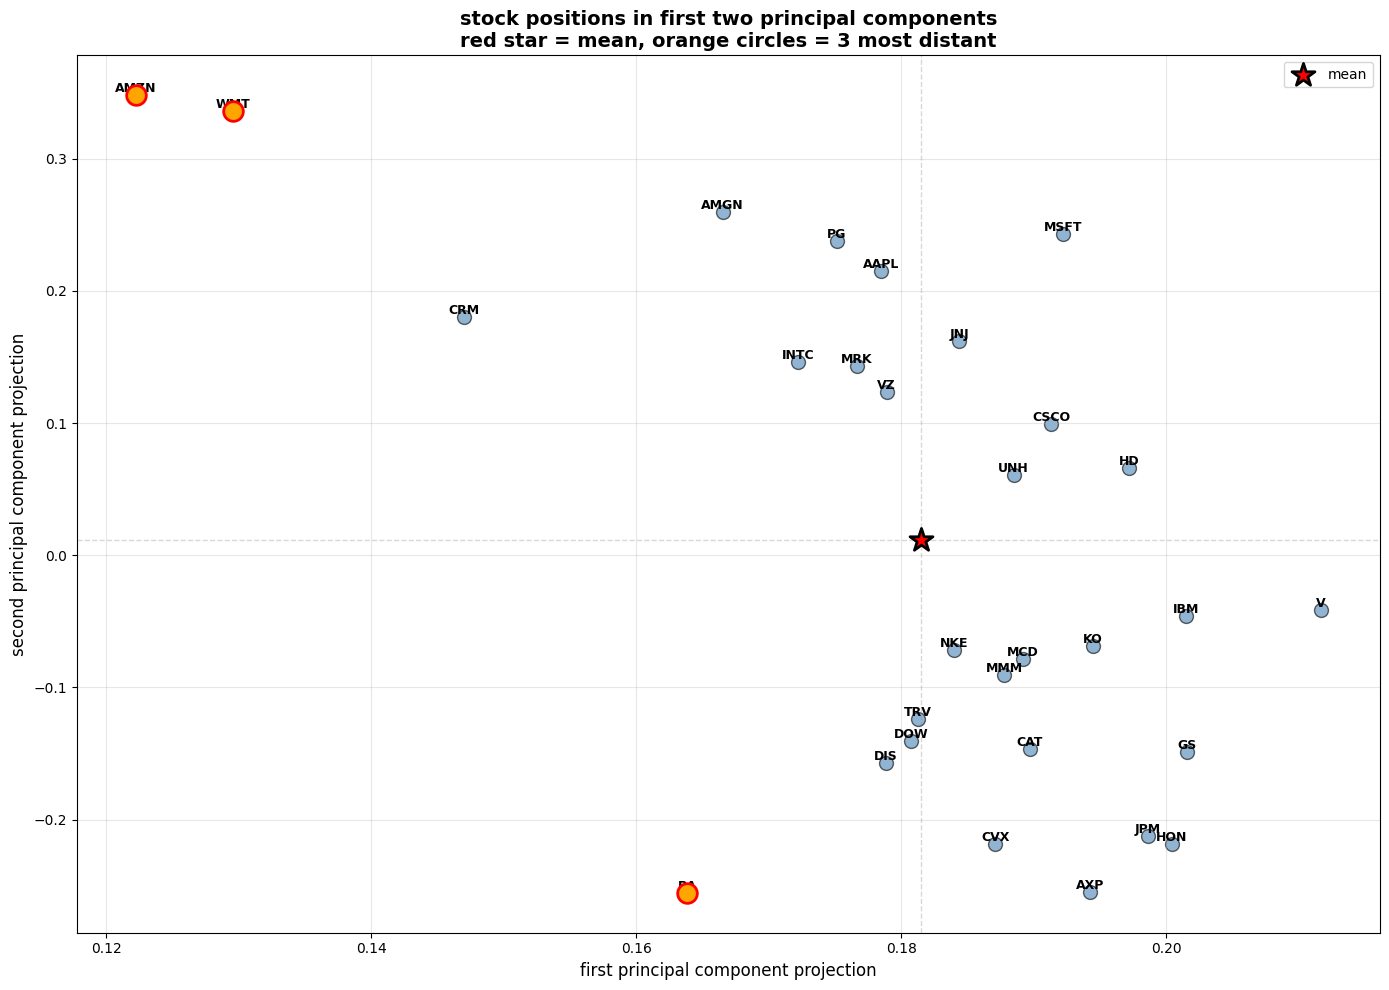

In [ ]:
print("question 3.5: identifying three most distant stocks")

distance_df = pd.DataFrame({
    'stock': dow_stocks,
    'pc1_projection': stock_pc1,
    'pc2_projection': stock_pc2,
    'distance_from_mean_pc1': distances_pc1,
    'distance_from_mean_pc2': distances_pc2,
    'euclidean_distance': euclidean_distances
})

print("\nall stocks with distances:")
print(distance_df.sort_values('euclidean_distance', ascending=False).to_string(index=False))

top3_pc1 = distance_df.nlargest(3, 'distance_from_mean_pc1')
print("\ntop 3 most distant stocks from mean (pc1):")
print(top3_pc1[['stock', 'pc1_projection', 'distance_from_mean_pc1']].to_string(index=False))

top3_pc2 = distance_df.nlargest(3, 'distance_from_mean_pc2')
print("\ntop 3 most distant stocks from mean (pc2):")
print(top3_pc2[['stock', 'pc2_projection', 'distance_from_mean_pc2']].to_string(index=False))

top3_euclidean = distance_df.nlargest(3, 'euclidean_distance')
print("\ntop 3 most distant stocks (euclidean distance):")
print(top3_euclidean[['stock', 'pc1_projection', 'pc2_projection', 'euclidean_distance']].to_string(index=False))

print("\n" + "="*80)
print("question 3.5: visualizing stock positions in pc space")

plt.figure(figsize=(14, 10))

plt.scatter(stock_pc1, stock_pc2, s=100, alpha=0.6, color='steelblue', edgecolors='black', linewidth=1)

for i, stock in enumerate(dow_stocks):
    plt.annotate(stock, (stock_pc1[i], stock_pc2[i]), fontsize=9,
                ha='center', va='bottom', fontweight='bold')

plt.scatter(mean_pc1_stocks, mean_pc2_stocks, s=300, color='red', marker='*',
           edgecolors='black', linewidth=2, label='mean', zorder=5)

top3_indices = distance_df.nlargest(3, 'euclidean_distance').index
for idx in top3_indices:
    plt.scatter(stock_pc1[idx], stock_pc2[idx], s=200, color='orange',
               edgecolors='red', linewidth=2, zorder=4)

plt.xlabel('first principal component projection', fontsize=12)
plt.ylabel('second principal component projection', fontsize=12)
plt.title('stock positions in first two principal components\nred star = mean, orange circles = 3 most distant',
         fontsize=14, fontweight='bold')
plt.axhline(y=mean_pc2_stocks, color='gray', linestyle='--', linewidth=1, alpha=0.3)
plt.axvline(x=mean_pc1_stocks, color='gray', linestyle='--', linewidth=1, alpha=0.3)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("question 3.5: analyzing why distant stocks are unusual")

print("\ndetailed analysis of top 3 most distant stocks:")

for idx in top3_indices:
    stock = dow_stocks[idx]
    returns = daily_returns[stock]

    print(f"\n{'='*60}")
    print(f"stock: {stock}")
    print(f"  pc1 projection: {stock_pc1[idx]:.4f}")
    print(f"  pc2 projection: {stock_pc2[idx]:.4f}")
    print(f"  euclidean distance from mean: {euclidean_distances[idx]:.4f}")
    print(f"\n  return statistics:")
    print(f"    mean daily return: {returns.mean():.6f} ({returns.mean()*100:.4f}%)")
    print(f"    std deviation: {returns.std():.6f} ({returns.std()*100:.4f}%)")
    print(f"    min return: {returns.min():.6f} ({returns.min()*100:.2f}%)")
    print(f"    max return: {returns.max():.6f} ({returns.max()*100:.2f}%)")
    print(f"    volatility rank: {(returns.std() > daily_returns.std()).sum()}/30")

    avg_corr_with_others = correlation_matrix[stock].drop(stock).mean()
    print(f"\n  correlation with other stocks:")
    print(f"    average correlation: {avg_corr_with_others:.4f}")
    print(f"    correlation rank: {(correlation_matrix[stock].drop(stock) < avg_corr_with_others).sum()}/29")


question 3.5: analyzing why distant stocks are unusual

detailed analysis of top 3 most distant stocks:

stock: AMZN
  pc1 projection: 0.1223
  pc2 projection: 0.3481
  euclidean distance from mean: 0.3417

  return statistics:
    mean daily return: 0.002437 (0.2437%)
    std deviation: 0.024260 (2.4260%)
    min return: -0.079221 (-7.92%)
    max return: 0.079295 (7.93%)
    volatility rank: 8/30

  correlation with other stocks:
    average correlation: 0.4028
    correlation rank: 15/29

stock: WMT
  pc1 projection: 0.1295
  pc2 projection: 0.3364
  euclidean distance from mean: 0.3289

  return statistics:
    mean daily return: 0.001023 (0.1023%)
    std deviation: 0.019881 (1.9881%)
    min return: -0.090710 (-9.07%)
    max return: 0.117085 (11.71%)
    volatility rank: 2/30

  correlation with other stocks:
    average correlation: 0.4258
    correlation rank: 15/29

stock: BA
  pc1 projection: 0.1638
  pc2 projection: -0.2555
  euclidean distance from mean: 0.2676

  return s